In [20]:
import sys
import os

# Add the root of the project to the path
this_path = os.path.abspath(os.getcwd())
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)
output_dir = os.path.join(this_path, 'datasets')

# init

In [37]:
import pandas as pd

source_file='icdar_train_df.csv' 
train_df = pd.read_csv(f"{this_path}\\datasets\\{source_file}")
modality="final"
gw=15
prop=1
n_cc=1
resolution=224
stride=int(resolution/2)
sort_by="black_ratio"
#i select the m patches per file that have the highest number of cc
m = 50
print(train_df.head())


   writer  isEng  same_text  \
0       1      0          0   
1       1      0          1   
2       1      1          0   
3       1      1          1   
4       2      0          0   

                                           file_name  male  index  
0  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     0      0  
1  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     0      1  
2  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     0      2  
3  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     0      3  
4  C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...     0      4  


# run

In [38]:
if modality=="final":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row_resolution, axis=1,args=(resolution,stride, n_cc)), []))
elif modality=="body":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row_body, axis=1,args=()), []))
elif modality=="patches":
    train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row, axis=1,args=(gw, n_cc,prop)), []))

train_df_expanded.head(10)

,writer,isEng,same_text,file_name,male,index,x,y,x2,y2,n_cc,black_ratio
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,1904,112,2128,336,2,0.000020
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,2016,112,2240,336,2,0.000020
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,1904,224,2128,448,2,0.000020
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,2016,224,2240,448,2,0.000020
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,0,336,224,560,3,0.000419
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,112,336,336,560,5,0.000618
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,224,336,448,560,6,0.002730
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,336,336,560,560,9,0.006896
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,448,336,672,560,13,0.011300
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,560,336,784,560,9,0.009925


In [39]:
train_df_expanded = train_df_expanded.reset_index(drop=True)
train_df_expanded.head(10)

,writer,isEng,same_text,file_name,male,index,x,y,x2,y2,n_cc,black_ratio
0,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,1904,112,2128,336,2,0.000020
1,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,2016,112,2240,336,2,0.000020
2,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,1904,224,2128,448,2,0.000020
3,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,2016,224,2240,448,2,0.000020
4,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,0,336,224,560,3,0.000419
5,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,112,336,336,560,5,0.000618
6,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,224,336,448,560,6,0.002730
7,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,336,336,560,560,9,0.006896
8,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,448,336,672,560,13,0.011300
9,1,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,0,560,336,784,560,9,0.009925


In [40]:
train_df_expanded_sorted = train_df_expanded.sort_values(by=sort_by, ascending=False)
train_df_expanded = train_df_expanded_sorted.groupby('file_name').head(m)   # Select top m patches per page

# Visual check

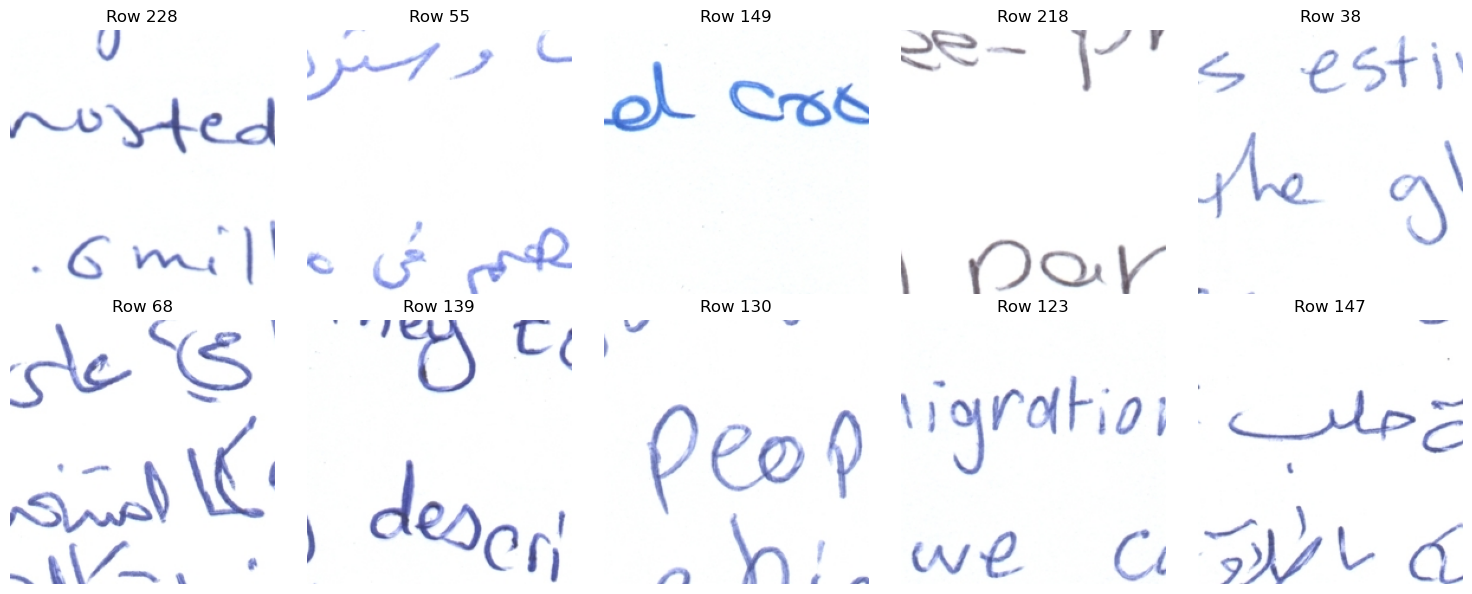

In [41]:
visualization.plot_cropped_sections(train_df_expanded)

# tests

In [42]:
tests.check_occurrences(train_df_expanded,count=4*m)

Each unique writer value occurs on exactly 200 rows.


# save

In [43]:
train_df_expanded['index']=train_df_expanded.index
train_df_expanded.head(10)

C:\Users\andre\AppData\Local\Temp\ipykernel_20720\1824186534.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_expanded['index']=train_df_expanded.index


,writer,isEng,same_text,file_name,male,index,x,y,x2,y2,n_cc,black_ratio
200923,200,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,200923,2576,2240,2800,2464,2,0.660296
200888,200,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,200888,2576,2128,2800,2352,2,0.558574
200924,200,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,200924,2688,2240,2912,2464,2,0.519571
200922,200,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,200922,2464,2240,2688,2464,3,0.463409
200889,200,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,200889,2688,2128,2912,2352,3,0.436224
200887,200,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,200887,2464,2128,2688,2352,2,0.404476
247756,244,1,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,247756,1680,1456,1904,1680,7,0.244380
85146,86,1,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,85146,1792,560,2016,784,15,0.234913
11479,12,1,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,11479,784,1232,1008,1456,27,0.231306
85507,86,1,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,85507,2128,1680,2352,1904,15,0.229632


In [44]:
prefix=os.path.splitext(source_file)[0]
output_file = os.path.join(output_dir, f"{prefix}_w_patches.csv")
train_df_expanded.to_csv(output_file, index=False)

print(f"Dataframe saved to {output_file}")

Dataframe saved to c:\Users\andre\VsCode\PD related projects\gender_detection\notebooks\pipeline_single_model\datasets\icdar_train_df_w_patches.csv


# easy access

In [16]:
def reload_modules():
    import importlib
    import utils.image_processing as image_processing
    import utils.file_IO as file_IO
    import utils.visualization as visualization
    import utils.tests as tests

    importlib.reload(file_IO)
    importlib.reload(image_processing)
    importlib.reload(visualization)
    importlib.reload(tests)

    return image_processing, file_IO, visualization, tests
image_processing, file_IO, visualization, tests = reload_modules()